# **IMPORT LIBRARY**

In [ ]:
# Install
!pip install google-play-scraper
!pip install optuna
!pip install sastrawi

# General
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import csv
import re
import string
import requests
import optuna
from io import StringIO
from google_play_scraper import app, reviews, Sort # Mengambil data aplikasi dan ulasan

# Pengaturan umum
pd.options.mode.chained_assignment = None
seed = 0
np.random.seed(seed)

# Preprocessing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt_tab')   # untuk word_tokenize
nltk.download('stopwords')   # untuk stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Training & Evaluation
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Visualization
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **SCRAPPING DATA**

In [ ]:
# Ambil semua ulasan dari aplikasi dengan ID tertentu
scrapreview, continuation_token = reviews(
    'com.bca.mybca.omni.android',  # ID aplikasi
    lang='id',                     # Bahasa ulasan
    country='id',                  # Negara asal ulasan
    sort=Sort.MOST_RELEVANT,       # Urutan ulasan
    count=10000                    # Maks jumlah ulasan
)

In [ ]:
# Menyimpan ke CSV
with open('ulasan_sentimen.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])  # Menulis header kolom
    for review in scrapreview:
        writer.writerow([review['content']])  # Menulis konten ulasan ke dalam file CSV

In [ ]:
df = pd.DataFrame(scrapreview)
df.shape
df.head()
df.to_csv('ulasan_sentimen.csv', index=False)

In [ ]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c9cb12be-610e-4e4a-bffd-c9ed1ba41bb6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"pertahankan performannya, sudah ringan dan leb...",5,566,2.6.1,2025-07-05 03:40:45,Terima kasih atas ulasannya. Semoga aplikasi m...,2025-07-05 03:48:18,2.6.1
1,0a6f4c28-79c0-4746-903d-27570c5e52a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi bermasalah, 3 bulan lalu ke blokir, s...",2,20,2.6.1,2025-07-12 11:22:01,Mohon maaf atas ketidaknyamanannya. Saran dan ...,2025-07-12 12:26:14,2.6.1
2,7b190236-3b73-4ca0-853f-d216514c4eca,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa setiap saya transaksi seringkali saldo ...,2,2,2.7.0,2025-07-23 15:49:24,Status transaksi PEND pada mutasi rekening di ...,2025-07-23 15:57:30,2.7.0
3,96a8ac7c-5b90-41b9-b5be-6630fa3f4e3b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus banget tapi sayangsering banget di suruh...,3,15,2.6.1,2025-07-21 03:37:29,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2025-07-21 04:00:27,2.6.1
4,5f11ea24-92f3-40c9-bac6-9291f50daa09,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi myBCA tampilannya modern dan fitur-fi...,4,2,2.7.0,2025-07-24 03:26:08,Terima kasih atas saran dan ulasannya. Saran d...,2025-07-24 05:57:59,2.7.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,fc3e2b5f-59aa-40dd-b2f8-28e99664273e,Ardiansyah Ardiansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,Login susah masuknya.verifikasi SMS lama kali ...,1,0,1.9.1,2023-08-04 01:52:50,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2023-08-04 02:07:31,1.9.1
9996,90ea62d7-631d-4f5c-9afa-298795025b60,Lila Sukmawati,https://play-lh.googleusercontent.com/a/ACg8oc...,"Gimana sii verifikasi kok gagal terus, udah la...",1,0,1.16.2,2024-01-07 04:29:47,"Mohon maaf atas ketidaknyamanannya, apabila Ba...",2024-01-07 05:00:22,1.16.2
9997,b8a2d328-6d35-4dd4-97f9-a09a2ff1d3b6,Adinda Putrianti Sholihah (Dinda),https://play-lh.googleusercontent.com/a-/ALV-U...,"Kesel udah berkali kali verifikasi wajah, gaga...",1,0,1.14.0,2023-10-28 09:49:08,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2023-10-28 09:52:36,1.14.0
9998,0a61e7a8-ed53-47e4-b9fb-afbd83f06368,Andy uvr,https://play-lh.googleusercontent.com/a/ACg8oc...,"Hari gini masih ngandelin sms,maksa harus kone...",1,0,None,2024-04-02 15:43:14,Mohon maaf atas ketidaknyamanannya. Ulasan Bap...,2024-04-02 16:16:32,None


# **CLEANING DATA**

In [ ]:
df = pd.DataFrame(scrapreview)

# Jumlah baris dan kolom
jumlah_ulasan, jumlah_kolom = df.shape
print("Jumlah ulasan yang berhasil diambil:", jumlah_ulasan)
print("Jumlah kolom dalam DataFrame:", jumlah_kolom)

Jumlah ulasan yang berhasil diambil: 10000
Jumlah kolom dalam DataFrame: 11


In [ ]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c9cb12be-610e-4e4a-bffd-c9ed1ba41bb6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"pertahankan performannya, sudah ringan dan leb...",5,566,2.6.1,2025-07-05 03:40:45,Terima kasih atas ulasannya. Semoga aplikasi m...,2025-07-05 03:48:18,2.6.1
1,0a6f4c28-79c0-4746-903d-27570c5e52a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi bermasalah, 3 bulan lalu ke blokir, s...",2,20,2.6.1,2025-07-12 11:22:01,Mohon maaf atas ketidaknyamanannya. Saran dan ...,2025-07-12 12:26:14,2.6.1
2,7b190236-3b73-4ca0-853f-d216514c4eca,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa setiap saya transaksi seringkali saldo ...,2,2,2.7.0,2025-07-23 15:49:24,Status transaksi PEND pada mutasi rekening di ...,2025-07-23 15:57:30,2.7.0
3,96a8ac7c-5b90-41b9-b5be-6630fa3f4e3b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus banget tapi sayangsering banget di suruh...,3,15,2.6.1,2025-07-21 03:37:29,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2025-07-21 04:00:27,2.6.1
4,5f11ea24-92f3-40c9-bac6-9291f50daa09,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi myBCA tampilannya modern dan fitur-fi...,4,2,2.7.0,2025-07-24 03:26:08,Terima kasih atas saran dan ulasannya. Saran d...,2025-07-24 05:57:59,2.7.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              10000 non-null  object        
 1   userName              10000 non-null  object        
 2   userImage             10000 non-null  object        
 3   content               10000 non-null  object        
 4   score                 10000 non-null  int64         
 5   thumbsUpCount         10000 non-null  int64         
 6   reviewCreatedVersion  8272 non-null   object        
 7   at                    10000 non-null  datetime64[ns]
 8   replyContent          10000 non-null  object        
 9   repliedAt             10000 non-null  datetime64[ns]
 10  appVersion            8272 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 859.5+ KB


In [ ]:
# Cek Missing Values
print(df.isnull().sum())

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    1728
at                         0
replyContent               0
repliedAt                  0
appVersion              1728
dtype: int64


In [ ]:
# Mengecek jumlah data duplikat
print(df.duplicated().sum())

0


In [ ]:
clean_df = df.copy()

# Hapus kolom yang tidak diinginkan
clean_df = clean_df.drop(columns= [
    'reviewId', 'userName', 'userImage', 'thumbsUpCount', 'score',
    'reviewCreatedVersion', 'replyContent', 'repliedAt', 'appVersion', 'at'
    ])

clean_df

,content
0,"pertahankan performannya, sudah ringan dan leb..."
1,"aplikasi bermasalah, 3 bulan lalu ke blokir, s..."
2,kenapa setiap saya transaksi seringkali saldo ...
3,bagus banget tapi sayangsering banget di suruh...
4,Aplikasi myBCA tampilannya modern dan fitur-fi...
...,...
9995,Login susah masuknya.verifikasi SMS lama kali ...
9996,"Gimana sii verifikasi kok gagal terus, udah la..."
9997,"Kesel udah berkali kali verifikasi wajah, gaga..."
9998,"Hari gini masih ngandelin sms,maksa harus kone..."


In [ ]:
# mendownload hasil cleaning dalam file csv
from google.colab import files

clean_df.to_csv('Data_clean.csv',index=False)

files.download('Data_clean.csv')

print("file ulasan sudah berhasil didownload!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

file ulasan sudah berhasil didownload!


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  10000 non-null  object
dtypes: object(1)
memory usage: 78.3+ KB


# **PREPROCESSING**

In [ ]:
# pola emoji & simbol non‑ASCII umum
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emotikon
    "\U0001F300-\U0001F5FF"  # simbol & pictograph
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # bendera
    "\U00002702-\U000027B0"  # dingbats
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE,
)

# Menghapus elemen-elemen tidak penting dari teks
def cleaningText(text: str) -> str:
    text = re.sub(r'@[A-Za-z0-9_]+',  '', text)      # mention
    text = re.sub(r'#[A-Za-z0-9_]+',  '', text)      # hashtag
    text = re.sub(r'RT\b',              '', text)    # RT
    text = re.sub(r'http\S+',           '', text)    # link
    text = re.sub(r'[0-9]+',            '', text)    # angka
    text = EMOJI_PATTERN.sub(' ', text)              # 🚫 emoji
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

# Mengubah semua huruf menjadi huruf kecil
def casefoldingText(text):
    return text.lower()

# Memecah kalimat menjadi token (kata-kata)
def tokenizingText(text):
    return word_tokenize(text)

# Menghapus kata-kata umum (stopwords)
def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update([
        'dan', 'atau', 'tetapi', 'tapi', 'lalu', 'kemudian', 'di', 'ke', 'dari', 'untuk',
        'pada', 'dengan', 'saya', 'kamu', 'dia', 'mereka', 'kita', 'ini', 'itu', 'adalah',
        'telah', 'akan', 'sedang', 'apa', 'siapa', 'mengapa', 'bagaimana', 'tidak', 'ya',
        'saja', 'aja', 'bahkan', 'namun', 'karena'
    ])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text


# Melakukan stemming (mengembalikan kata ke bentuk dasar)
def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    words = text.split()
    stemmed = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed)

# Menggabungkan daftar kata menjadi kalimat
def toSentence(list_words):
     return ' '.join(list_words)

In [ ]:
slangwords = {
    "ga": "tidak", "gk": "tidak", "gak": "tidak", "otp": "kode verifikasi", "bsa": "bisa",
    "gamasuk": "tidak masuk", "udah": "sudah", "udh": "sudah", "tp": "tapi", "trs": "terus",
    "ribet": "rumit", "fix": "perbaikan", "ampas": "tidak berguna", "mahal dikit": "sedikit mahal",
    "tdk": "tidak", "tp": "tetapi", "tapi": "tetapi", "dgn": "dengan", "apl": "aplikasi",
    "fine²": "baik-baik saja", "muncul²": "muncul-muncul", "bug": "masalah teknis", "hrs": "harus",
    "lancar": "berjalan baik", "dikit": "sedikit", "cba": "coba", "tetep": "tetap", "kyk": "seperti",
    "emg": "memang", "bgt": "sangat", "banget": "sangat", "kok": "kenapa", "lemot": "lambat",
    "tf": "transfer", "smua": "semua", "jd": "jadi", "pake": "gunakan", "pakai": "gunakan",
    "cm": "cuma", "adapalah": "ada saja", "gimna": "bagaimana", "blm": "belum", "skrg": "sekarang",
    "dr": "dari", "klo": "kalau", "klw": "kalau", "karna": "karena", "yg": "yang", "dlu": "dulu",
    "bener": "benar", "nih": "ini", "aja": "saja", "kayak": "seperti", "gitu": "begitu", "kan": "bukan",
    "bikin": "buat", "capek": "lelah", "bosen": "bosan", "nomer": "nomor", "hp": "ponsel",
    "cs": "layanan pelanggan", "otomatis": "automatis", "gbsa": "tidak bisa", "gimana": "bagaimana",
    "wkwk": "tertawa", "hadeh": "mengeluh", "e-ktp": "KTP elektronik", "mutasi": "riwayat transaksi",
    "top up": "isi saldo", "vc": "video call", "paswod": "password", "tepasang": "terpasang",
    "sadonya": "saldonya", "sampe": "sampai", "kebuka": "terbuka", "kebanyakan": "terlalu banyak"
}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        # Remove punctuation for better matching
        clean_word = word.lower().strip('.,!?;:"\'')
        if clean_word in slangwords:
            replacement = slangwords[clean_word]
            # Preserve original capitalization
            if word[0].isupper():
                replacement = replacement.capitalize()
            fixed_words.append(replacement)
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [ ]:
!pip install tqdm

In [ ]:
from tqdm.notebook import tqdm
tqdm.pandas()

clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_stemming'] = clean_df['text_stopword'].progress_apply(lambda tokens: stemmingText(' '.join(tokens)).split())
clean_df['text_akhir'] = clean_df['text_stemming'].apply(lambda words: ' '.join(words))

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
clean_df

,content,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_stemming,text_akhir
0,"pertahankan performannya, sudah ringan dan leb...",pertahankan performannya sudah ringan dan lebi...,pertahankan performannya sudah ringan dan lebi...,pertahankan performannya sudah ringan dan lebi...,"[pertahankan, performannya, sudah, ringan, dan...","[pertahankan, performannya, ringan, responsif,...","[tahan, forman, ringan, responsif, beda, versi...",tahan forman ringan responsif beda versi saran...
1,"aplikasi bermasalah, 3 bulan lalu ke blokir, s...",aplikasi bermasalah bulan lalu ke blokir suda...,aplikasi bermasalah bulan lalu ke blokir suda...,aplikasi bermasalah bulan lalu ke blokir sudah...,"[aplikasi, bermasalah, bulan, lalu, ke, blokir...","[aplikasi, bermasalah, blokir, telepon, layana...","[aplikasi, masalah, blokir, telepon, layan, la...",aplikasi masalah blokir telepon layan langgan ...
2,kenapa setiap saya transaksi seringkali saldo ...,kenapa setiap saya transaksi seringkali saldo ...,kenapa setiap saya transaksi seringkali saldo ...,kenapa setiap saya transaksi seringkali saldo ...,"[kenapa, setiap, saya, transaksi, seringkali, ...","[transaksi, seringkali, saldo, ngga, langsung,...","[transaksi, seringkali, saldo, ngga, langsung,...",transaksi seringkali saldo ngga langsung masuk...
3,bagus banget tapi sayangsering banget di suruh...,bagus banget tapi sayangsering banget di suruh...,bagus banget tapi sayangsering banget di suruh...,bagus sangat tetapi sayangsering sangat di sur...,"[bagus, sangat, tetapi, sayangsering, sangat, ...","[bagus, sayangsering, suruh, perbarui, teruspa...","[bagus, sayangsering, suruh, baru, teruspadaha...",bagus sayangsering suruh baru teruspadahal tgl...
4,Aplikasi myBCA tampilannya modern dan fitur-fi...,Aplikasi myBCA tampilannya modern dan fiturfit...,aplikasi mybca tampilannya modern dan fiturfit...,aplikasi mybca tampilannya modern dan fiturfit...,"[aplikasi, mybca, tampilannya, modern, dan, fi...","[aplikasi, mybca, tampilannya, modern, fiturfi...","[aplikasi, mybca, tampil, modern, fiturfiturny...",aplikasi mybca tampil modern fiturfiturnya bag...
...,...,...,...,...,...,...,...,...
9995,Login susah masuknya.verifikasi SMS lama kali ...,Login susah masuknyaverifikasi SMS lama kali t...,login susah masuknyaverifikasi sms lama kali t...,login susah masuknyaverifikasi sms lama kali t...,"[login, susah, masuknyaverifikasi, sms, lama, ...","[login, susah, masuknyaverifikasi, sms, kali, ...","[login, susah, masuknyaverifikasi, sms, kali, ...",login susah masuknyaverifikasi sms kali kirim
9996,"Gimana sii verifikasi kok gagal terus, udah la...",Gimana sii verifikasi kok gagal terus udah lap...,gimana sii verifikasi kok gagal terus udah lap...,bagaimana sii verifikasi kenapa gagal terus su...,"[bagaimana, sii, verifikasi, kenapa, gagal, te...","[sii, verifikasi, gagal, laporan, halobca, ajah]","[sii, verifikasi, gagal, lapor, halobca, ajah]",sii verifikasi gagal lapor halobca ajah
9997,"Kesel udah berkali kali verifikasi wajah, gaga...",Kesel udah berkali kali verifikasi wajah gagal...,kesel udah berkali kali verifikasi wajah gagal...,kesel sudah berkali kali verifikasi wajah gaga...,"[kesel, sudah, berkali, kali, verifikasi, waja...","[kesel, berkali, kali, verifikasi, wajah, gaga...","[kesel, kali, kali, verifikasi, wajah, gagal, ...",kesel kali kali verifikasi wajah gagal mesti s...
9998,"Hari gini masih ngandelin sms,maksa harus kone...",Hari gini masih ngandelin smsmaksa harus konek...,hari gini masih ngandelin smsmaksa harus konek...,hari gini masih ngandelin smsmaksa harus konek...,"[hari, gini, masih, ngandelin, smsmaksa, harus...","[gini, ngandelin, smsmaksa, konek, mbca, sms, ...","[gin, ngandelin, smsmaksa, konek, mbca, sms, i...",gin ngandelin smsmaksa konek mbca sms ituhabis...


In [ ]:
clean_df.to_csv('processing.csv', index=False)

# **LABELLING**

In [ ]:
# Muat kamus kata positif dari GitHub
import requests, csv
from io import StringIO

lexicon_positive = dict()
resp = requests.get('https://raw.githubusercontent.com/firdahum/pi/main/lexicon_positive.csv')
if resp.status_code == 200:
    reader = csv.reader(StringIO(resp.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

# Muat kamus kata negatif dari GitHub
lexicon_negative = dict()
resp = requests.get('https://raw.githubusercontent.com/firdahum/pi/main/lexicon_negative.csv')
if resp.status_code == 200:
    reader = csv.reader(StringIO(resp.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

In [ ]:
def lexicon(text):
    score = 0
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]  # tambah skor jika positif

    for word in text:
        if word in lexicon_negative:
            score += lexicon_negative[word]  # kurangi skor jika negatif

    # positif jika skor > 0, negatif jika skor < 0, netral jika skor == 0
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [ ]:
# Menerapkan fungsi analisis sentimen pada data teks yang telah dibersihkan
results = clean_df['text_stopword'].apply(lexicon)

# Memisahkan hasil analisis menjadi dua kolom: skor dan label polaritas
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

# Menampilkan jumlah masing-masing kategori polaritas
print(clean_df['polarity'].value_counts())

polarity
negative    5487
positive    3694
neutral      819
Name: count, dtype: int64


In [ ]:
def analyzetweets(clean_df):
    pd.set_option('display.max_colwidth', 3000)

    # Positive Tweets
    positive_tweets = clean_df[clean_df['polarity'] == 'positive']
    positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
    positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False).reset_index(drop=True)
    positive_tweets.index += 1

    # Negative Tweets
    negative_tweets = clean_df[clean_df['polarity'] == 'negative']
    negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
    negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True).head(10).reset_index(drop=True)
    negative_tweets.index += 1

    # Neutral Tweets
    neutral_tweets = clean_df[clean_df['polarity'] == 'neutral']
    neutral_tweets = neutral_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
    neutral_tweets = neutral_tweets.sort_values(by='polarity_score', ascending=False).reset_index(drop=True)
    neutral_tweets.index += 1

    # Word Cloud
    list_words = ''
    for tweet in clean_df['text_stopword']:
        for word in tweet:
            list_words += ' ' + word

    wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title('Word Cloud of Tweets Data', fontsize=18)
    ax.grid(False)
    ax.imshow(wordcloud)
    fig.tight_layout(pad=0)
    ax.axis('off')
    plt.show()

    return positive_tweets, negative_tweets, neutral_tweets

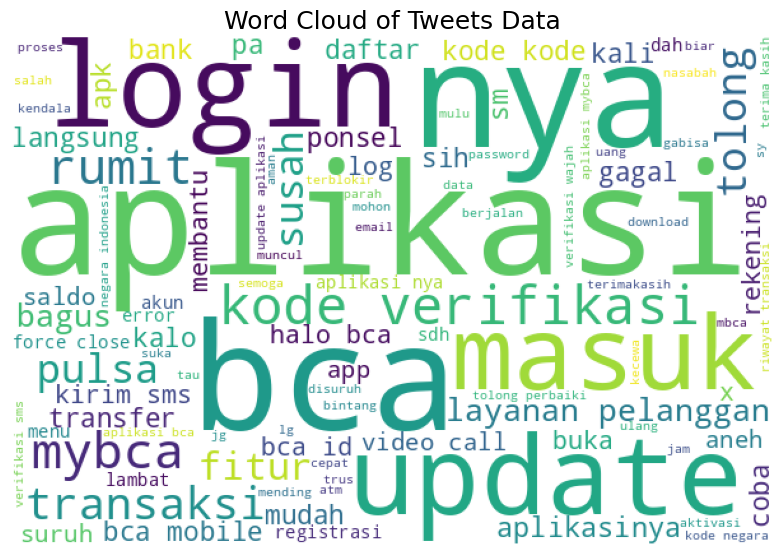

In [ ]:
positive_tweets, negative_tweets, neutral_tweets = analyzetweets(clean_df)

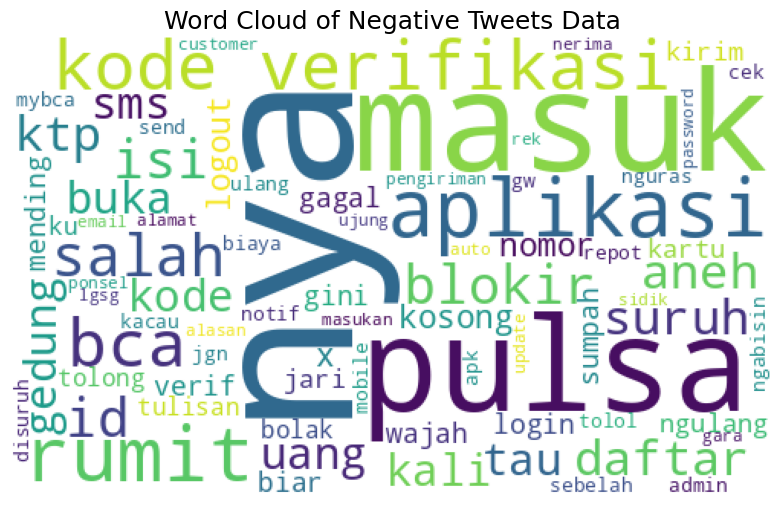

In [ ]:
# Kumpulkan semua kata dari tweet negatif
list_words = ''
for tweet in negative_tweets['text_stopword']:
    for word in tweet:
        list_words += ' ' + word

# Buat WordCloud dari kata-kata yang terkumpul
wordcloud = WordCloud(width=500, height=300, background_color='white', min_font_size=10).generate(list_words)

# Tampilkan WordCloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

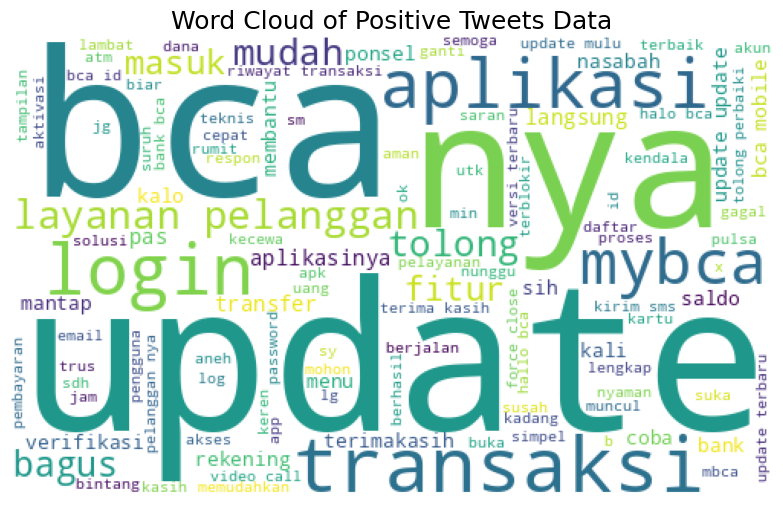

In [ ]:
# Kumpulkan semua kata dari tweet positif
list_words = ''
for tweet in positive_tweets['text_stopword']:
    for word in tweet:
        list_words += ' ' + word

# Buat dan tampilkan WordCloud
wordcloud = WordCloud(width=500, height=300, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

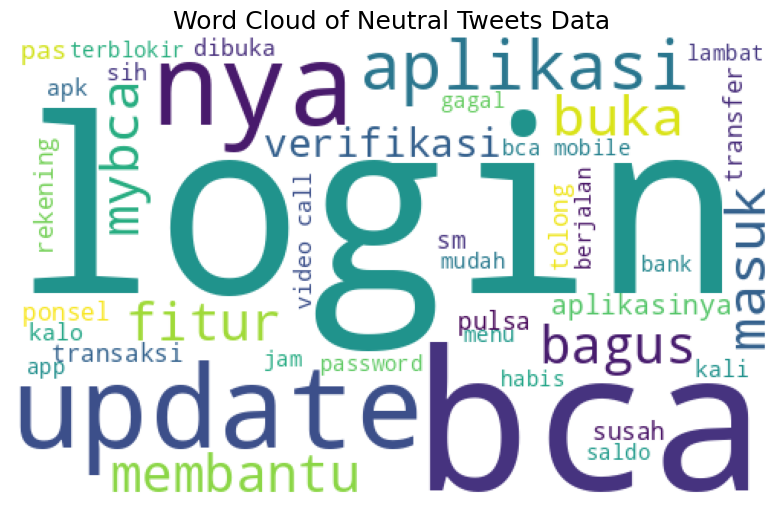

In [ ]:
# Kumpulkan semua kata dari tweet netral
list_words = ''
for tweet in neutral_tweets['text_stopword']:
    for word in tweet:
        list_words += ' ' + word

# Buat dan tampilkan WordCloud
wordcloud = WordCloud(width=500, height=300, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Neutral Tweets Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

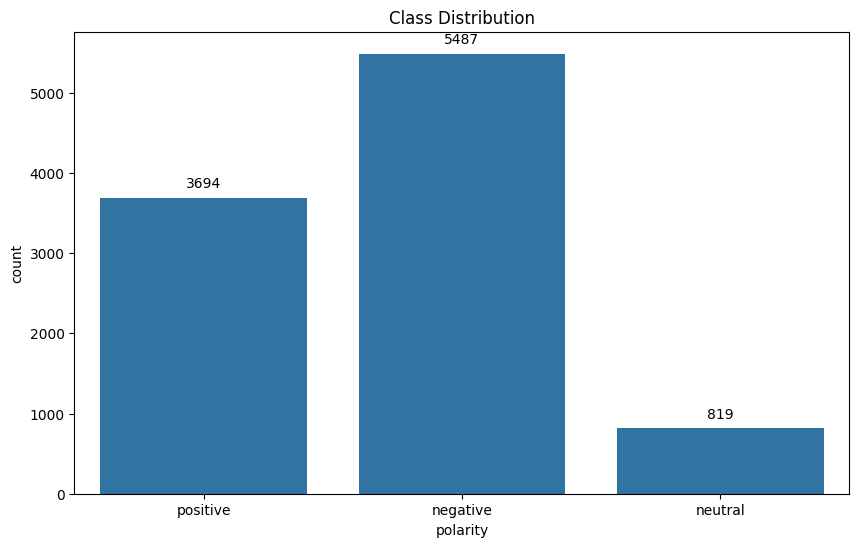

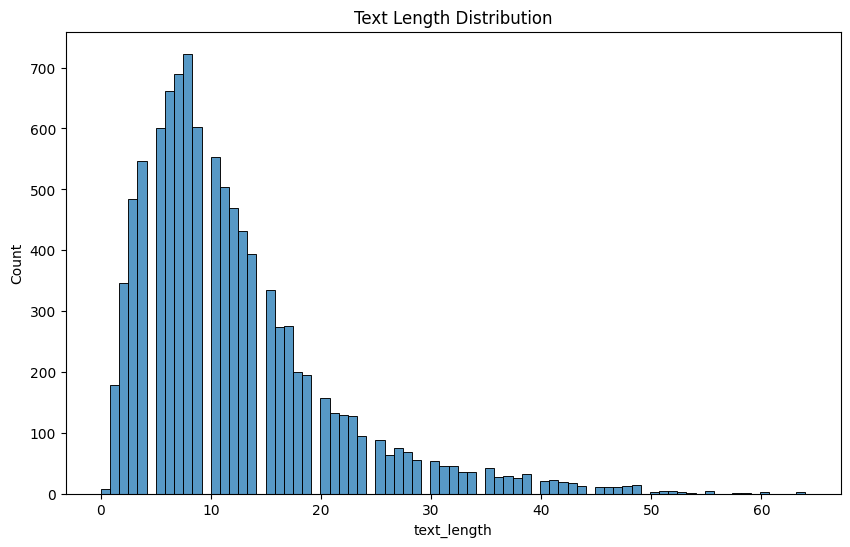

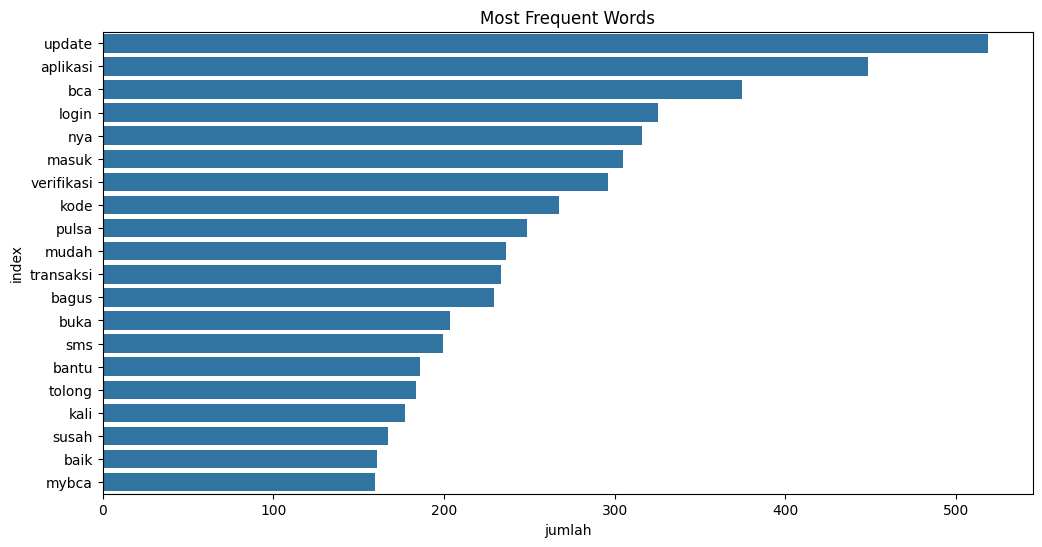

In [ ]:
# Visualisasi Distribusi Kelas Sentimen
plt.figure(figsize=(10, 6))
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

# Menampilkan jumlah pada masing-masing bar
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center',
                             xytext=(0, 10),
                             textcoords='offset points')
plt.show()

# Visualisasi Panjang Teks Review
plt.figure(figsize=(10, 6))
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Visualisasi Kata yang Paling Sering Muncul
plt.figure(figsize=(12, 6))
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

In [ ]:
clean_df.head(2)

,content,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_stemming,text_akhir,polarity_score,polarity,text_length
0,"pertahankan performannya, sudah ringan dan lebih responsif, beda jauh dengan versi sebelumnya, hanya sedikit saran untuk space iklan atau pengumuman sebaiknya cukup ditampilkan saat di latar awal saja sebelum login. Jadi, kalau sudah login tidak ada lagi spam space iklan atau pengumuman tersebut yang menurut saya malah terkesan pemborosan dan menggangu, sehingga pada akhirnya diharapkan tampilan aplikasi lebih simpel, praktis dan lebih responsif lagi tanpa ngelag terimakasih",pertahankan performannya sudah ringan dan lebih responsif beda jauh dengan versi sebelumnya hanya sedikit saran untuk space iklan atau pengumuman sebaiknya cukup ditampilkan saat di latar awal saja sebelum login Jadi kalau sudah login tidak ada lagi spam space iklan atau pengumuman tersebut yang menurut saya malah terkesan pemborosan dan menggangu sehingga pada akhirnya diharapkan tampilan aplikasi lebih simpel praktis dan lebih responsif lagi tanpa ngelag terimakasih,pertahankan performannya sudah ringan dan lebih responsif beda jauh dengan versi sebelumnya hanya sedikit saran untuk space iklan atau pengumuman sebaiknya cukup ditampilkan saat di latar awal saja sebelum login jadi kalau sudah login tidak ada lagi spam space iklan atau pengumuman tersebut yang menurut saya malah terkesan pemborosan dan menggangu sehingga pada akhirnya diharapkan tampilan aplikasi lebih simpel praktis dan lebih responsif lagi tanpa ngelag terimakasih,pertahankan performannya sudah ringan dan lebih responsif beda jauh dengan versi sebelumnya hanya sedikit saran untuk space iklan atau pengumuman sebaiknya cukup ditampilkan saat di latar awal saja sebelum login jadi kalau sudah login tidak ada lagi spam space iklan atau pengumuman tersebut yang menurut saya malah terkesan pemborosan dan menggangu sehingga pada akhirnya diharapkan tampilan aplikasi lebih simpel praktis dan lebih responsif lagi tanpa ngelag terimakasih,"[pertahankan, performannya, sudah, ringan, dan, lebih, responsif, beda, jauh, dengan, versi, sebelumnya, hanya, sedikit, saran, untuk, space, iklan, atau, pengumuman, sebaiknya, cukup, ditampilkan, saat, di, latar, awal, saja, sebelum, login, jadi, kalau, sudah, login, tidak, ada, lagi, spam, space, iklan, atau, pengumuman, tersebut, yang, menurut, saya, malah, terkesan, pemborosan, dan, menggangu, sehingga, pada, akhirnya, diharapkan, tampilan, aplikasi, lebih, simpel, praktis, dan, lebih, responsif, lagi, tanpa, ngelag, terimakasih]","[pertahankan, performannya, ringan, responsif, beda, versi, saran, space, iklan, pengumuman, ditampilkan, latar, login, login, spam, space, iklan, pengumuman, terkesan, pemborosan, menggangu, diharapkan, tampilan, aplikasi, simpel, praktis, responsif, ngelag, terimakasih]","[tahan, forman, ringan, responsif, beda, versi, saran, space, iklan, umum, tampil, latar, login, login, spam, space, iklan, umum, kes, boros, menggangu, harap, tampil, aplikasi, simpel, praktis, responsif, ngelag, terimakasih]",tahan forman ringan responsif beda versi saran space iklan umum tampil latar login login spam space iklan umum kes boros menggangu harap tampil aplikasi simpel praktis responsif ngelag terimakasih,6,positive,29
1,"aplikasi bermasalah, 3 bulan lalu ke blokir, sudah telepon cs katanya sudah di unblock, lalu pas coba login masih ada bacaan password atau bca id salah, padahal sudah diisi dengan benar, lalu beberapa minggu kemudian coba lagi, sudah ganti password pun pas di klik login tetep ada notif bca id atau password salah, sudah hubungi cs 4x, baiknya pelayanan mengenai MyBCA juga tersedia offline agar memudahkan jika ada kendala.",aplikasi bermasalah bulan lalu ke blokir sudah telepon cs katanya sudah di unblock lalu pas coba login masih ada bacaan password atau bca id salah padahal sudah diisi dengan benar lalu beberapa minggu kemudian coba lagi sudah ganti password pun pas di klik l

### TF-IDF

In [ ]:
def prepare_features(clean_df):
    # Pisahkan data menjadi fitur dan label
    X = clean_df['text_akhir']
    y = clean_df['polarity']

    # Ekstraksi fitur TF-IDF
    tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8)
    X_tfidf = tfidf.fit_transform(X)

    # Buat dataframe dari hasil ekstraksi
    features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# **MODELLING**

## **DATA SPLITTING**

In [ ]:
def prepare_features(clean_df):
    # Pisahkan data menjadi fitur dan label
    X = clean_df['text_akhir']
    y = clean_df['polarity']

    # Ekstraksi fitur TF-IDF
    tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8)
    X_tfidf = tfidf.fit_transform(X)

    # Buat dataframe dari hasil ekstraksi
    features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

    # Split data ke training dan testing
    X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

    return X, y, tfidf, X_tfidf, features_df, X_train, X_test, y_train, y_test

In [ ]:
X, y, tfidf, X_tfidf, features_df, X_train, X_test, y_train, y_test = prepare_features(clean_df)

In [ ]:
features_df.head()

,abis,admin,akses,aktif,aktivasi,akun,aman,aneh,apk,aplikasi,...,ubah,ulang,update,utk,verifikasi,versi,via,video,wajah,wifi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.147412,...,0.0,0.000000,0.0,0.0,0.0,0.33641,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.076218,...,0.0,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.213759,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.377214,0.0,0.000000,0.090306,...,0.0,0.158379,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0


## **OVERSAMPLING**

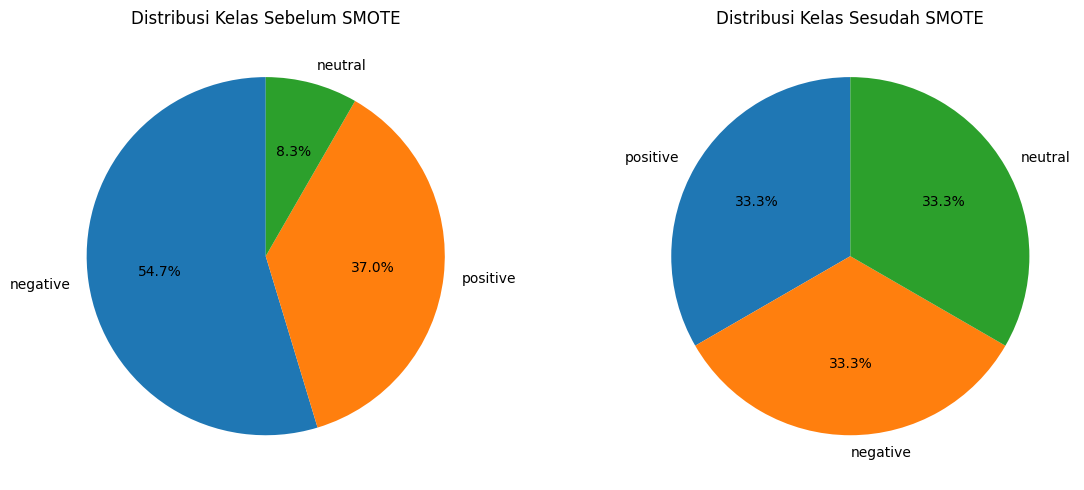

In [ ]:
# Hitung distribusi kelas sebelum SMOTE
before_counts = y_train.value_counts()

# Terapkan SMOTE ke data latih
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Hitung distribusi kelas sesudah SMOTE
after_counts = pd.Series(y_train_sm).value_counts()

# Buat pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart sebelum SMOTE
axes[0].pie(before_counts, labels=before_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribusi Kelas Sebelum SMOTE')

# Pie chart sesudah SMOTE
axes[1].pie(after_counts, labels=after_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribusi Kelas Sesudah SMOTE')

plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame({
    "Sebelum SMOTE": before_counts,
    "Sesudah SMOTE": after_counts
})

,Sebelum SMOTE,Sesudah SMOTE
polarity,,
negative,4374,4374
neutral,665,4374
positive,2961,4374


# **SVM**

In [ ]:
def objective(trial):
    # Suggest hyperparameters
    C = trial.suggest_float('C', 0.1, 30, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1.0, log=True)

    model_svm = SVC(C=C, gamma=gamma, kernel='rbf')

    # Fit pada data train
    model_svm.fit(X_train.toarray(), y_train)

    # Prediksi dan hitung akurasi
    y_pred = model_svm.predict(X_test.toarray())
    return accuracy_score(y_test, y_pred)

# Buat study baru
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)  # Kamu bisa naikkan n_trials jika ingin hasil lebih optimal

# Tampilkan hasil terbaik
print("Best Parameters:", study.best_params)
print(f"Best Accuracy: {study.best_value * 100:.2f}%")

# --- Train ulang model_svm terbaik ---
best_svc = SVC(**study.best_params, kernel='rbf')
best_svc.fit(X_train.toarray(), y_train)

# Prediksi dan evaluasi
y_pred_test_svm = best_svc.predict(X_test.toarray())
y_pred_train_svm = best_svc.predict(X_train.toarray())

print(f"Akurasi Training: {accuracy_score(y_train, y_pred_train_svm) * 100:.2f}%")
print(f"Akurasi testing: {accuracy_score(y_test, y_pred_test_svm) * 100:.2f}%")

[I 2025-08-02 09:42:12,629] A new study created in memory with name: no-name-628c08e5-9951-4632-882e-935ce43ffcfe
[I 2025-08-02 09:42:25,934] Trial 0 finished with value: 0.774 and parameters: {'C': 6.451919221231866, 'gamma': 0.005116520809597121}. Best is trial 0 with value: 0.774.
[I 2025-08-02 09:42:38,576] Trial 1 finished with value: 0.7325 and parameters: {'C': 1.4473805865516063, 'gamma': 0.006178230564084789}. Best is trial 0 with value: 0.774.
[I 2025-08-02 09:42:47,044] Trial 2 finished with value: 0.8045 and parameters: {'C': 2.410890495445108, 'gamma': 0.16599680259736851}. Best is trial 2 with value: 0.8045.
[I 2025-08-02 09:43:01,287] Trial 3 finished with value: 0.6945 and parameters: {'C': 0.48316102509054565, 'gamma': 0.011476809564129642}. Best is trial 2 with value: 0.8045.
[I 2025-08-02 09:43:15,016] Trial 4 finished with value: 0.5565 and parameters: {'C': 2.474739138600843, 'gamma': 0.0001405657765231425}. Best is trial 2 with value: 0.8045.
[I 2025-08-02 09:43:2

Best Parameters: {'C': 3.3811783452690007, 'gamma': 0.21489200995048638}
Best Accuracy: 81.00%
Akurasi Training: 84.26%
Akurasi testing: 81.00%


# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Buat model_dt dengan default parameter
model_dt = DecisionTreeClassifier(random_state=42)

# Training
model_dt.fit(X_train, y_train)

# Prediksi
y_pred_train_dt = model_dt.predict(X_train)
y_pred_test_dt = model_dt.predict(X_test)

# Evaluasi akurasi
print(f"Akurasi Data Training: {accuracy_score(y_train, y_pred_train_dt) * 100:.2f}%")
print(f"Akurasi Data Testing: {accuracy_score(y_test, y_pred_test_dt) * 100:.2f}%")

Akurasi Data Training: 98.19%
Akurasi Data Testing: 70.65%


# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Buat model_rf Random Forest dengan parameter default
model_rf = RandomForestClassifier(random_state=42)

# Training
model_rf.fit(X_train, y_train)

# Prediksi
y_pred_train_rf = model_rf.predict(X_train)
y_pred_test_rf = model_rf.predict(X_test)

# Evaluasi akurasi
print(f"Akurasi Data Training: {accuracy_score(y_train, y_pred_train_rf) * 100:.2f}%")
print(f"Akurasi Data Testing: {accuracy_score(y_test, y_pred_test_rf) * 100:.2f}%")

Akurasi Data Training: 98.19%
Akurasi Data Testing: 77.90%


# **EVALUASI MODEL**

In [ ]:
def evaluate_model(model, X, y_true, title="Evaluation"):
    # Prediksi
    y_pred = model.predict(X)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    # Evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"==Evaluation Report==")
    print(f"Accuracy : {accuracy * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall   : {recall * 100:.2f}%")
    print(f"F1 Score : {f1 * 100:.2f}%")
    print("\n")
    print("\n            === Classification Report ===")
    print("\n")
    print(classification_report(y_true, y_pred, zero_division=0))

In [ ]:
evaluate_model(best_svc, X_test.toarray(), y_test)

In [ ]:
def evaluate_model(model_name, y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    print("Classification Report:")
    print(classification_report(y_true, y_pred))

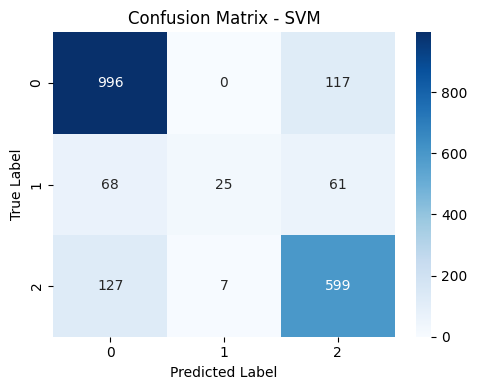

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.89      0.86      1113
     neutral       0.78      0.16      0.27       154
    positive       0.77      0.82      0.79       733

    accuracy                           0.81      2000
   macro avg       0.80      0.62      0.64      2000
weighted avg       0.81      0.81      0.79      2000



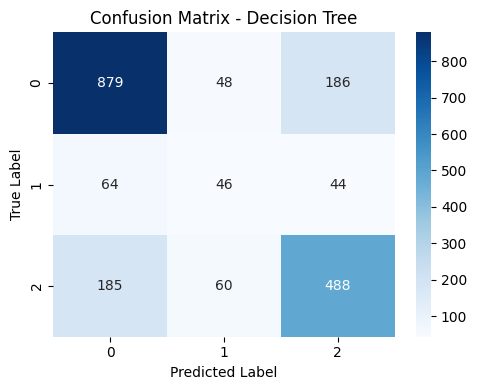

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.79      0.78      1113
     neutral       0.30      0.30      0.30       154
    positive       0.68      0.67      0.67       733

    accuracy                           0.71      2000
   macro avg       0.59      0.58      0.59      2000
weighted avg       0.71      0.71      0.71      2000



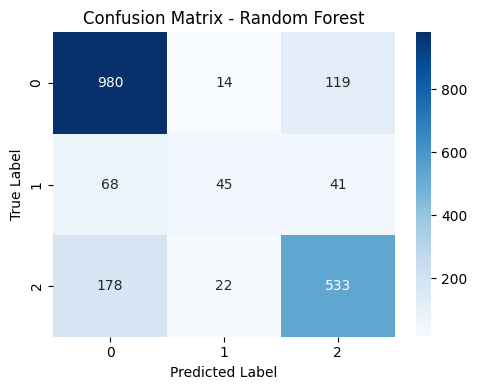

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.88      0.84      1113
     neutral       0.56      0.29      0.38       154
    positive       0.77      0.73      0.75       733

    accuracy                           0.78      2000
   macro avg       0.71      0.63      0.66      2000
weighted avg       0.77      0.78      0.77      2000



In [ ]:
evaluate_model("SVM", y_test, y_pred_test_svm)
evaluate_model("Decision Tree", y_test, y_pred_test_dt)
evaluate_model("Random Forest", y_test, y_pred_test_rf)

# **Inference**

In [ ]:
sentimen_map = {
    'positive': 'POSITIF',
    'negative': 'NEGATIF',
    'neutral': 'NETRAL'
}

for i in range(3):
    kalimat_baru = input(f"[{i+1}/3] Masukkan kalimat: ")

    # Transform dan prediksi
    X_baru = tfidf.transform([kalimat_baru])
    hasil_prediksi = best_svc.predict(X_baru.toarray())

    print(f"Sentimen kalimat tersebut adalah: {sentimen_map[hasil_prediksi[0]]}\n")